# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | ChatGPT|
| Used for |Understanding the assignment requirements, guidance on data preprocessing, data augmentation, ConvNet design, debugging Python/Keras code, and interpretation guidance.  |
| Verified how | Ran the notebook end-to-end, checked test accuracy > 65%|
| Not used for | AI was not used to generate or alter the reported experimental results.|


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [2]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Convert pixel values from 0–255 to 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten labels from shape (n, 1) to (n,)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

# Create validation split: last 5,000 training images
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Training shape:", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:", x_test.shape, y_test.shape)

Training shape: (45000, 32, 32, 3) (45000,)
Validation shape: (5000, 32, 32, 3) (5000,)
Test shape: (10000, 32, 32, 3) (10000,)


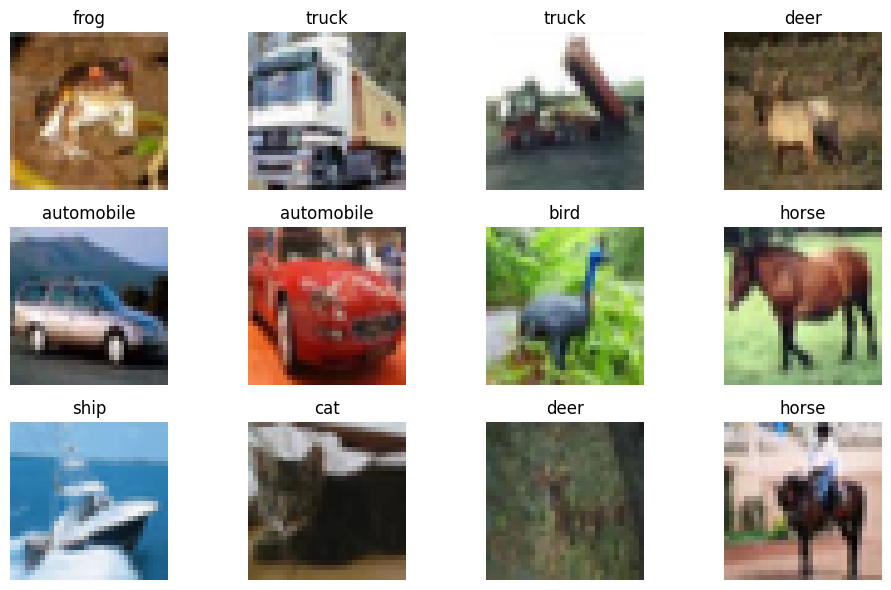

In [3]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


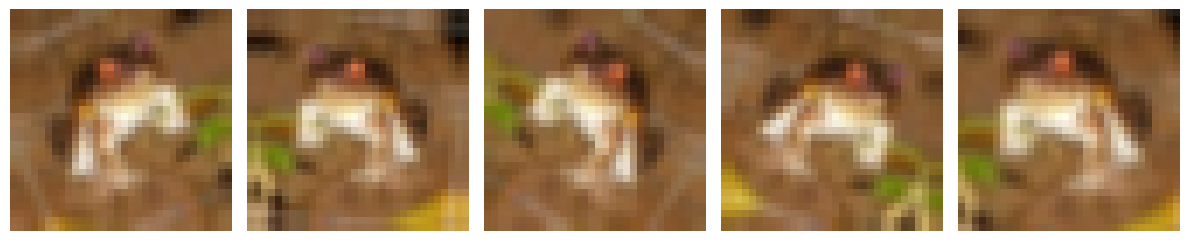

In [ ]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

data_augmentation
sample = x_train[0]

plt.figure(figsize=(12, 3))

for i in range(5):
    augmented = data_augmentation(
        np.expand_dims(sample, axis=0),
        training=True
    )[0]

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented.numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()


## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [ ]:
inputs = keras.Input(shape=(32, 32, 3))

# Data augmentation
x = data_augmentation(inputs)

# First convolution block
x = layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    activation="relu",
    name="conv2d_1"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Conv2D(
    32,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Second convolution block
x = layers.Conv2D(
    64,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Conv2D(
    64,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Third convolution block
x = layers.Conv2D(
    128,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Conv2D(
    128,
    (3, 3),
    padding="same",
    activation="relu"
)(x)

x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.30)(x)

# Classifier
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.40)(x)

outputs = layers.Dense(
    10,
    activation="softmax",
    name="classifier"
)(x)

# Create model
model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

print("Model ready:", model is not None)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,706 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

Model ready: True


## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


In [11]:
# TODO: fit
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1,
)

# TODO: evaluate once on the test set

test_loss, test_acc = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc:.2f}")
#print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc if test_acc is not None else None}")


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7796 - loss: 0.6547 - val_accuracy: 0.8068 - val_loss: 0.5892
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.7783 - loss: 0.6471 - val_accuracy: 0.8062 - val_loss: 0.5801
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.7893 - loss: 0.6204 - val_accuracy: 0.7982 - val_loss: 0.6176
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.7839 - loss: 0.6276 - val_accuracy: 0.8172 - val_loss: 0.5455
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.7828 - loss: 0.6291 - val_accuracy: 0.7924 - val_loss: 0.6538
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.7926 - loss: 0.6083 - val_accuracy: 0.7528 - val_loss: 0.7612
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.7889 - loss: 0.6165 - val_accuracy: 0.7946 - val_loss: 0.6241
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7945 - loss: 0.6043 - 

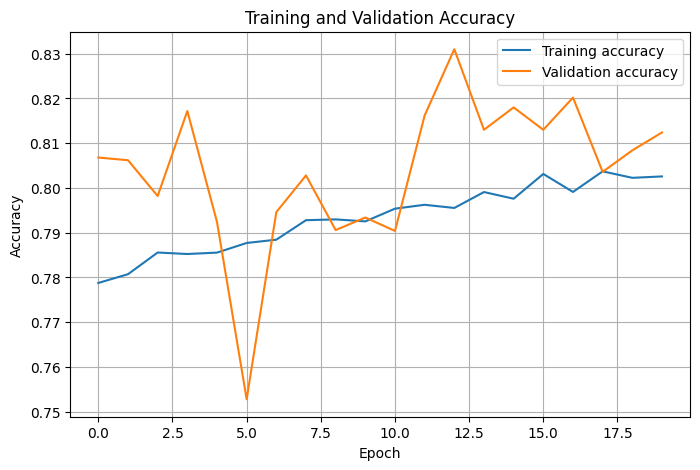

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


Filter shape: (3, 3, 3, 32)
Bias shape: (32,)


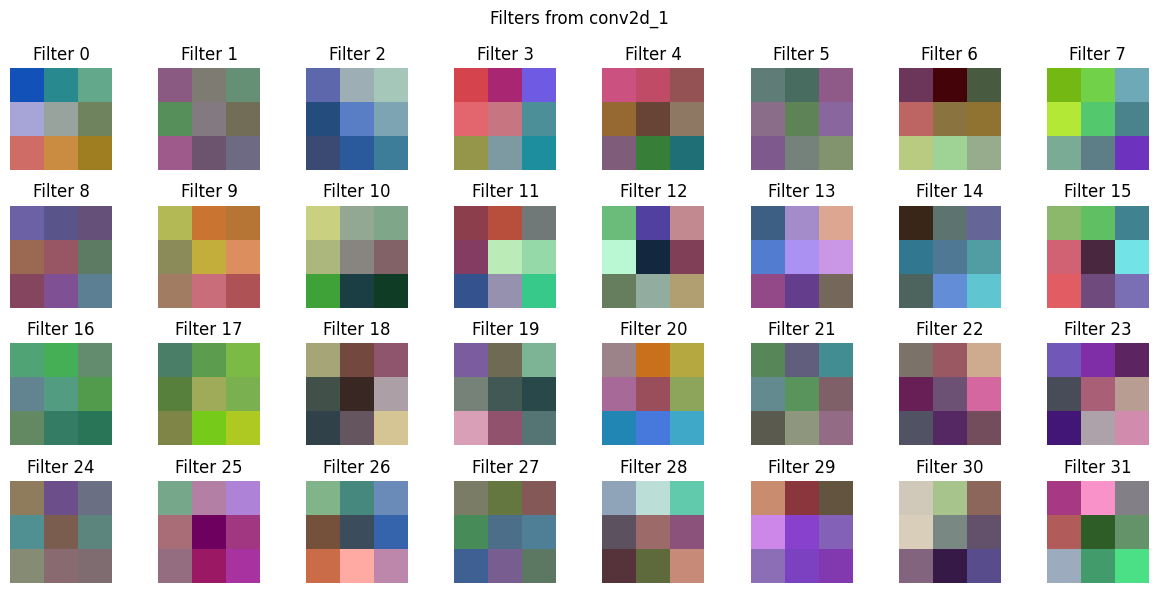

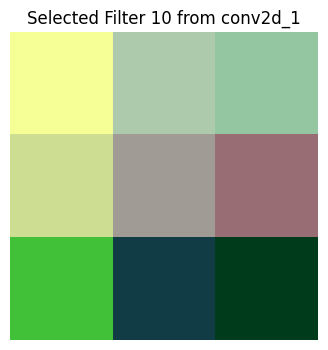

Visualisation layer (Moodle a4_filter_layer): conv2d_1
Selected filter for interpretation: Filter 10


In [ ]:

VIS_LAYER = "conv2d_1"
SELECTED_FILTER = 10
# Get the convolutional layer
conv_layer = model.get_layer(VIS_LAYER)

# Extract filters and biases
filters, biases = conv_layer.get_weights()

print("Filter shape:", filters.shape)
print("Bias shape:", biases.shape)

# Normalise filters for visualisation
filters_min = filters.min()
filters_max = filters.max()

filters_norm = (
    filters - filters_min
) / (
    filters_max - filters_min + 1e-8
)

# Plot all 32 filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters_norm[:, :, :, i])
    ax.axis("off")
    ax.set_title(f"Filter {i}")

plt.suptitle(f"Filters from {VIS_LAYER}")
plt.tight_layout()
plt.show()

# Display Filter 10 separately
selected_filter = filters[:, :, :, SELECTED_FILTER]

# Rescale selected filter to 0-1
f_min = selected_filter.min()
f_max = selected_filter.max()

if f_max > f_min:
    selected_filter_display = (
        selected_filter - f_min
    ) / (f_max - f_min)
else:
    selected_filter_display = selected_filter

plt.figure(figsize=(4, 4))
plt.imshow(selected_filter_display)
plt.title(f"Selected Filter {SELECTED_FILTER} from {VIS_LAYER}")
plt.axis("off")
plt.show()

# Information for Moodle
print(f"Visualisation layer (Moodle a4_filter_layer): {VIS_LAYER}")
print(f"Selected filter for interpretation: Filter {SELECTED_FILTER}")

## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


*Your interpretation here.*
visualised Filter 10 from the conv2d_1 layer. The filter shows a noticeable contrast between the brighter centre region and the darker surrounding regions. This suggests that the filter may respond to local changes in colour or brightness, such as edges, boundaries or small contrast patterns in an image. Since this is an early convolutional layer, it is expected to learn simple visual features rather than complete objects such as cars or animals. These basic features can later be combined by deeper convolutional layers to recognise more complex shapes and object characteristics.